In [1]:
# Import libraries and setup matplotlib defaults
from matplotlib import pyplot as pl
import matplotlib.dates as mdates
import pandas as pd
import numpy as np
pl.style.use('bmh')
clist = ['#377eb8', '#e41a1c', '#4daf4a', '#984ea3', '#ff7f00',
         '#ffff33', '#a65628', '#f781bf', '#999999']
prop_cycle = pl.cycler(color=clist)

from matplotlib.colors import ListedColormap
cmap = ListedColormap([clist[0], clist[1]])

pl.rcParams.update({
    'axes.prop_cycle': prop_cycle,
    'lines.linewidth': 2,
    'font.size': 18,
    'figure.figsize': [8, 5],
    'figure.subplot.left': 0.125,
    'figure.subplot.right': 0.95,
    'figure.subplot.bottom': 0.15})

days_per_year = 365.25

In [2]:
%%capture
# set up path to include parent directory
import sys
sys.path.append('../')

# Import everything from the data_utils library
from data_utils import *

# Load the talk data
talk_data = get_only_talks(load_data())

In [3]:
apostle_bio_data = pd.read_csv('../data/apostles_bio_data.csv',
                               index_col=0, parse_dates=['Born', 'Died'])
apostle_calling_data = pd.read_csv('../data/apostles_calling_data.csv',
                                   index_col=0, parse_dates=['date_start', 'date_end'])

apostle_data = apostle_bio_data[['Name', 'Born', 'Died']].join(
    apostle_calling_data[apostle_calling_data['position']=='LDS Church Apostle'].drop(
        columns=['Name', 'position']))

## Data cleanup
# 1. deal with the Orsons, so their dates don't mess up the seniority calculations
special_cases = ['Orson Pratt', 'Orson Hyde']
for name in special_cases:
    ref_data = apostle_calling_data[(apostle_calling_data['Name']==name) &
                                    (apostle_calling_data['position']=='Quorum of the Twelve Apostles')
                                   ].sort_values('date_end').iloc[-1].transpose()
    apostle_data.loc[apostle_data['Name']==name, 'date_start'] = ref_data['date_start']
    apostle_data.loc[apostle_data['Name']==name, 'date_end'] = ref_data['date_end']    

# 2. deal with BY Jr, whose seniority date starts later
apostle_data.loc[apostle_data['Name']=='Brigham Young Jr.', 'date_start'] = pd.to_datetime('1868-06-22')

# 3. deal with the non-quorum apostles
data = (('John Willard Young', 'date_start', 'Counselor in the First Presidency'),
        ('John Willard Young', 'date_end', 'First Counselor in the First Presidency'),
        ('Daniel H. Wells', 'date_end', 'Second Counselor in the First Presidency'),
        ('Alvin R. Dyer', 'date_end', 'Counselor in the First Presidency'))
for name, dt_type, calling in data:
    apostle_data.loc[apostle_data['Name']==name, dt_type] = \
    apostle_calling_data.loc[(apostle_calling_data['Name']==name) &
                         (apostle_calling_data['position']==calling), dt_type]

apostle_data['short name'] = apostle_data['Name'].map(shorten_name)
apostle_sn_dict = apostle_data[['Name', 'short name']].set_index('Name').to_dict()['short name']

president_list = apostle_calling_data[apostle_calling_data['position']=='President of the Church']['Name'].to_list()

apostle_data['office']=0
apostle_data.loc[apostle_data['Name'].isin(president_list), 'office']=1



date_diff_years = lambda df, x, y: ((df[x]-df[y]).dt.days/days_per_year).round(2)
apostle_data['age_end'] = date_diff_years(apostle_data, 'date_end', 'Born')
apostle_data['age_at_call'] = date_diff_years(apostle_data, 'date_start', 'Born')
apostle_data['service_years'] = date_diff_years(apostle_data, 'date_end', 'date_start')


ad_seniority = apostle_data.loc[~apostle_data['date_start'].isna(), [
    'Name', 'Born', 'Died', 'age_end', 'date_start', 'date_end']].sort_values('date_start').reset_index().copy()

In [4]:
def calc_alt_end_date(df, age):
    df['date_end_alt'] = pd.concat([df['Born'] + np.timedelta64(
        int(age*days_per_year), 'D'), df['date_end']], axis=1).min(1)
    return df

def get_p_list_age(df, age, idx_list):
    ad_selected = df.loc[idx_list].copy()
    ad_selected = calc_alt_end_date(ad_selected, age)

    ad_selected['date_start_p'] = ad_selected['date_end_alt'].shift(1, fill_value=pd.to_datetime('1847-12-27'))
    ad_final = ad_selected[ad_selected['date_start_p']<'2026-01-01'].copy()
    ad_final['p_time'] = date_diff_years(ad_final, 'date_end_alt', 'date_start_p')
    ad_final['p_start_age'] = date_diff_years(ad_final, 'date_start_p', 'Born')
    return ad_final


ea_data = pd.DataFrame(index=(70, 75, 80, 85, 90, 105),
                       columns=('idx_list','count', 'retired', 'mean time'))
for end_age in ea_data.index:
    ads_copy = ad_seniority.copy()
    ads_copy = calc_alt_end_date(ads_copy, end_age)

    idx = 0
    idxlist = [idx]
    idx = np.argmax(ads_copy['date_end_alt']>ads_copy['date_end_alt'][idx])
    while idx>0:
        idxlist.append(idx)
        idx = np.argmax(ads_copy['date_end_alt']>ads_copy['date_end_alt'][idx])

    ea_data.loc[end_age, 'idx_list'] = idxlist
    pd_df = get_p_list_age(ads_copy, end_age, idxlist)

    ea_data.loc[end_age, 'count'] = len(pd_df)+1
    ea_data.loc[end_age, 'retired'] = (pd_df['date_end_alt']!=pd_df['Died']).sum()
    ea_data.loc[end_age, 'mean time'] = pd_df['p_time'][:-1].mean()

In the 1980s, a new policy was introduced of giving members of the Seventy and Presiding Bishopric emeritus status when they reach the age of 70. In contrast, apostles and members of the First Presidency continue to serve until they die. Since the 1980s, while Seventies have obviously become younger as a group, the average age of the apostles has [increased somewhat](https://qhspencer.github.io/lds-data-analysis/apostles/) from around 70 years in the 1980s to over 75 years in the 2020s. This, and the recent death of President Nelson at the extraordinary age of 101 has led some to speculate about the benefits of having emeritus status for the apostles as well. So, what would be the effect of emeritus status for apostles on the presidency of the church if such a scheme had been in place for the last 150 years?

The birth of the current succession scheme (in which the president of the Quorum of the Twelve becomes the next president of the church after the current one dies) can be traced to the presidency of Brigham Young, emerging from the succession crisis after the death of Joseph Smith. Since then only minor changes have been made, mainly involving adjustments to how seniority order is established. For purposes of this analysis, we begin with Brigham Young's presidency, and calculate the effects of age cutoffs on who becomes president of the church given the seniority order of all apostles who have served since that time.

The current system has the effect of making those who live to be the oldest disproportionately more likely to become president of the church. A fixed retirement age scheme is likely to give more apostles the chance to become president of the church, which would have the effect of more total presidents serving for shorter terms. A retrospective analysis of the birth and death dates of all apostles since Brigham Young bears this out. The chart below shows the number of presidents of the church we would have had as of 2025, as a function of the retirement age, from 70 to 90 years old, and including no retirement age. With no retirement age, Dallin H. Oaks recently became the 18th president of the church. Under a system with a retirement age of 70, Ullisses Soares, currently the second most junior apostle, would now be serving as 32nd president of the church.

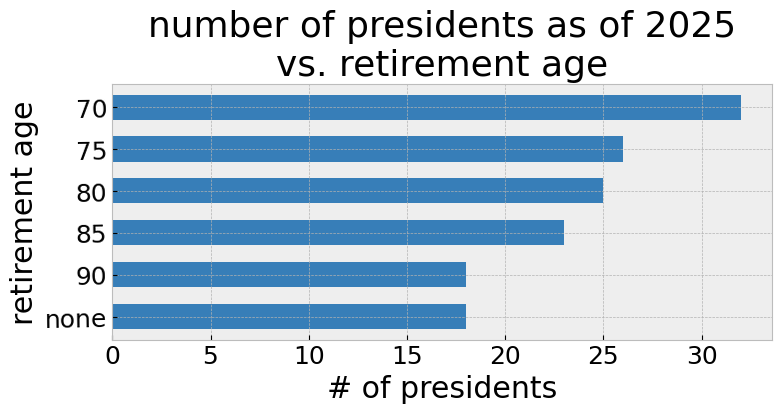

In [5]:
_ = ea_data.rename(index={105: 'none'})['count'][::-1].plot.barh(
    figsize=(8,3.5), rot=True, width=0.6, title='number of presidents as of 2025\nvs. retirement age',
    xlabel='# of presidents', ylabel='retirement age')

As expected, the increase in number of presidents of the church significantly affects the average tenure of each president. The chart below shows the average tenure in years per president as the retirement age increases. Under the current system, the average tenure is over 11 years, while a retirement age of 70 would result in an average tenure of under 6 years, a reduction of nearly 50%.

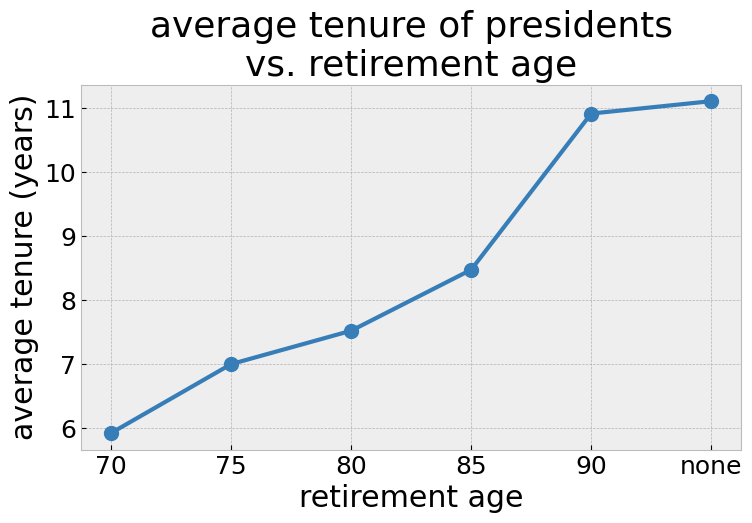

In [6]:
_ = ea_data.rename(index={105: 'none'})['mean time'].plot(
    title='average tenure of presidents\nvs. retirement age',
    xlabel='retirement age', ylabel='average tenure (years)', marker='o', ms=10, lw=3)

The chart below shows the fraction of church presidents who would end their term by retirement rather than death under a fixed retirement age. Remarkably, nearly half would retire if the retirement age were set at 90, while that number increases to over 80% as the age goes down to 70.

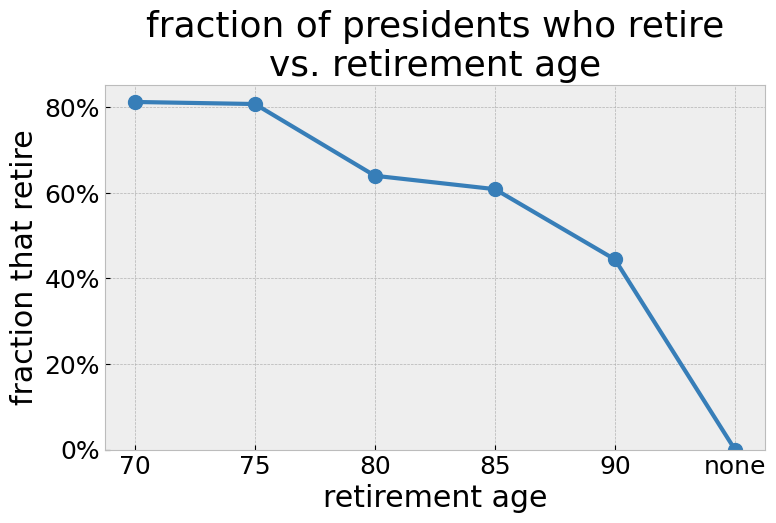

In [7]:
ax = ((ea_data['retired']-1)/ea_data['count']).rename(index={105: 'none'}).plot(
    title='fraction of presidents who retire\nvs. retirement age',
    xlabel='retirement age', ylabel='fraction that retire', marker='o', ms=10, lw=3, ylim=[0, None])
from matplotlib.ticker import PercentFormatter
ax.yaxis.set_major_formatter(PercentFormatter(xmax=1))

To understand some of the quirks that result from a fixed retirement age, it is instructive to create a visual timeline. The chart below shows such a timeline for each of the retirement ages that have been considered here. Where possible, regions of the timeline have been labeled with the name of the church president or potential church president.

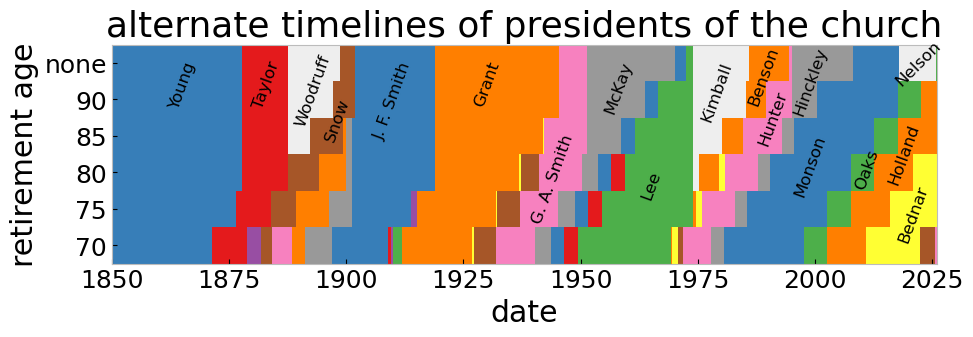

In [8]:
# create a single dataframe containing start and end dates and duration times for all timelines
get_age_data = lambda a: get_p_list_age(ad_seniority, a, ea_data.loc[a, 'idx_list'])

df_list = []
for val in ea_data.index.to_list():
    df_list.append(get_age_data(val)[['Name', 'date_start_p', 'date_end_alt']].set_index('Name').rename(
        columns={'date_start_p':f'date_start_{val}', 'date_end_alt': f'date_end_{val}'}))

all_dates = pd.concat(df_list, axis='columns').join(apostle_data.set_index('Name')[['date_start']], how='left').sort_values(
    'date_start').drop(columns='date_start').rename(
    columns={'date_start_105':'date_start_none', 'date_end105':'date_end_none'})


# generate the plot
fig, ax = pl.subplots(figsize=(10,3))

cols = all_dates.columns[::2].str.split('_').str[-1]
duration = (all_dates[all_dates.columns[1::2]] - all_dates[all_dates.columns[::2]].values)
duration.columns = duration.columns.str.split('_').str[-1]
start = all_dates[all_dates.columns[::2]]
start.columns = start.columns.str.split('_').str[-1]

for idx in duration.index:
    pl.barh(cols, width=duration.loc[idx], left=start.loc[idx], height=1)

ax.set_title('alternate timelines of presidents of the church')
ax.set_ylabel('retirement age')
ax.set_xlabel('date')
ax.set_xlim([pd.to_datetime('1850-01-01'), pd.to_datetime('2026-01-01')])
ax.set_ylim((-0.5,5.5))
ax.xaxis_date()
ax.set_xticks(pd.to_datetime(['1850-01-01', '1875-01-01', '1900-01-01', '1925-01-01',
                              '1950-01-01', '1975-01-01', '2000-01-01', '2025-01-01']))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.grid(False)


text_args = {'size':12, 'rotation':70, 'verticalalignment':'top', 'horizontalalignment':'center'}
ax.text(pd.to_datetime('1865-01-01'), 5.1, 'Young', **text_args)
ax.text(pd.to_datetime('1883-01-01'), 5.1, 'Taylor', **text_args)
ax.text(pd.to_datetime('1893-01-01'), 5.3, 'Woodruff', **text_args)
ax.text(pd.to_datetime('1898-01-01'), 4.1, 'Snow', **text_args)
ax.text(pd.to_datetime('1910-01-01'), 5.1, 'J. F. Smith', **text_args)
ax.text(pd.to_datetime('1930-01-01'), 5.1, 'Grant', **text_args)
ax.text(pd.to_datetime('1944-01-01'), 3.1, 'G. A. Smith', **text_args)
ax.text(pd.to_datetime('1958-01-01'), 5.1, 'McKay', **text_args)
ax.text(pd.to_datetime('1965-01-01'), 2.1, 'Lee', **text_args)
ax.text(pd.to_datetime('1979-01-01'), 5.1, 'Kimball', **text_args)
ax.text(pd.to_datetime('1989-01-01'), 5.5, 'Benson', **text_args)

ax.text(pd.to_datetime('1991-01-01'), 4.3, 'Hunter', **text_args)
ax.text(pd.to_datetime('1999-01-01'), 5.5, 'Hinckley', **text_args)
ax.text(pd.to_datetime('1999-01-01'), 3.1, 'Monson', **text_args)
ax.text(pd.to_datetime('2022-01-01'), 5.7, 'Nelson', **{**text_args, **{'rotation':45}})
ax.text(pd.to_datetime('2011-01-01'), 2.7, 'Oaks', **text_args)
ax.text(pd.to_datetime('2019-01-01'), 3.4, 'Holland', **text_args)
_=ax.text(pd.to_datetime('2021-01-01'), 1.7, 'Bednar', **text_args)

# Implications

This chart illustrates a number of effects that arise from fixed retirement ages.

## 1. The forward shift
One effect immediately apparent from the chart is the effect of shifting presidencies forward in time. Thomas S. Monson, who served as president from 2007 to 2018, would have instead served from 1980 to 1997 under a 70-year-old retirement age. The one president of the church known for his relatively young death (in his mid 70s) was Harold B. Lee. In his case, a retirement age has the effect of substantially lengthening his presidency (from 1 year to 20 years).

## 2. Presidencies that never happen
Certain presidents of the church assumed the office very late in life. The effect of a retirement age is that they never become president at all. This is true in the case of Wilford Woodruff, Spencer W. Kimball, and Russell M. Nelson. Other presidencies still happen, but get substantially shortened. This is the case for David O. McKay (from 19 years to 3 years) and Gordon B. Hinckley (from 13 years to 3 years).


## 3. Birth date quirks
With younger retirement ages, it is differences in birth dates rather than death dates that become the primary determinants for how long someone serves as president. This has the effect of creating a number of extraordinarily short terms for presidents. The most extreme example is Robert D. Hales (1932-2017), who was behind Dallin H. Oaks in seniority and was born exactly 12 days after Oaks. He lived to 85, so any fixed retirement age at 85 years or younger creates a scenario where Oaks retires, Hales becomes eligible to serve as president of the church, but then hits the retirement age himself 12 days later. (Note that the time was too short to be visible in the chart above.)

In addition, the following scenarios are created with a retirement age of 70:
* Orson Pratt and Franklin D. Richards serve as president (for a combined total of 13 years) between John Taylor and Lorenzo Snow.
* Erastus Snow and George Q. Cannon serve (for a combined total of 3 years) between Lorenzo Snow and Joseph F. Smith.
* Moses Thatcher, Francis M. Lyman, and John Henry Smith serve (for a combined total of 3 years) between Joseph F. Smith and Heber J. Grant.
* Rudger Clawson serves for a year followed by Reed Smoot for another 5 years before George Albert Smith.
* Steven L. Richards serves for 3 years between Joseph Fielding Smith and Harold B. Lee.
* Mark E. Peterson and Richard L. Evans each serve for about one year between Ezra Taft Benson and Howard W. Hunter.


# How would a retirement age this effect notable events from the past?
We know from various published histories that certain events, such as the 1978 revelation allowing priesthood and temple access regardless of race, depended heavily on certain personalities (both presence and absence). Joseph Fielding Smith and Harold B. Lee are known to have strongly opposed efforts a decade earlier to make the change, and Mark E. Peterson gave some of the more overtly racist sermons in general conference during his time. A relatively young retirement age means Spencer W. Kimball never becomes president of the church, but it also gives a longer and much earlier term to Howard W. Hunter, who might well have been the one to make the change. Under a retirement age of 70, Hunter serves as president of the church 1971-1977. Making the change in policy would have required persuading a much younger group of apostles than were in place in 1978, so it seems quite plausible he might have been the one to do it and could have done so as early as 1971.

Another notable event was the 1995 publication of the family proclamation. This is unlikely to have been significantly affected by a relatively young retirement age as Thomas S. Monson would have been president of the church at the time, to be succeeded soon thereafter by Dallin H. Oaks. Both are big supporters of the proclamation, having [spoken about it](https://qhspencer.github.io/lds-data-analysis/proclamation/) regularly in general conference. However, with Oaks retired from the presidency as early as 2002, the document may have had less of a long-term influence given that far fewer of today's more junior apostles regularly talk about it.

# Conclusion
The key insight from this analysis seems to be that introducing a fixed retirement age for apostles while retaining the current succession scheme produces some odd results. While some past presidents of the church have served for a fairly short time due to unexpected death, sometimes at a relatively young age, most likely the First Presidency and Quorum of the Twelve Apostles would prefer not to set up a system that knowingly sets up such scenarios in advance, most notably the potential 12-day term of Robert D. Hales. It is unlikely we will see a fixed retirement age adopted unless they are willing to substantially change the process for selecting new presidents of the church at the same time. A possible more likely alternative is the adoption of voluntary retirement when an apostle feels his health no longer allows him to carry out the job, similar to Pope Benedict XVI's unprecedented desicion to voluntarily retire as pope. One possible situation where we might see changes made to succession is a scenario where the president of the church dies, and the next most senior apostle is too ill to take over, something which has not yet happened. Several past presidents of the church became incapacitated in office (McKay, Kimball, Benson, Monson) but only after having served for a few years in relatively good health.

### Appendix: table of data featured in timeline chart
Because some presidential terms in the timeline chart were very short and hard to see, below is the raw data for reference. Date ranges are given to the nearest year for readability.

In [9]:
years_table = pd.DataFrame()
for a, b in all_dates.columns.values.reshape((-1,2)):
    years_table[a.split('_')[-1]] = (all_dates[a].dt.year.fillna(0).astype(int).astype(str) + '-' + \
                                     np.where(all_dates[b]>'2026-01-01', 'present',
                                              all_dates[b].dt.year.fillna(0).astype(int).astype(str))).replace('0-0', '')

years_table

,70,75,80,85,90,none
Name,,,,,,
Brigham Young,1847-1871,1847-1876,1847-1877,1847-1877,1847-1877,1847-1877
John Taylor,1871-1878,1876-1883,1877-1887,1877-1887,1877-1887,1877-1887
Wilford Woodruff,,,,1887-1892,1887-1897,1887-1898
Orson Pratt,1878-1881,,,,,
Franklin D. Richards I,1888-1891,1889-1896,1894-1899,1899-1899,,
Charles C. Rich,,1883-1883,,,,
Lorenzo Snow,1881-1884,1883-1889,1887-1894,1892-1899,1897-1901,1898-1901
Erastus Snow,1884-1888,,,,,
George Q. Cannon,1891-1897,1896-1901,1899-1901,1899-1901,,


In [10]:
# Setup show/hide source code box
from IPython.display import HTML

HTML('''<script>
code_show=true; 
function code_toggle() {
 if (code_show){
 $('div.input').hide();
 } else {
 $('div.input').show();
 }
 code_show = !code_show
} 
$( document ).ready(code_toggle);
</script>
<form action="javascript:code_toggle()">
<input type="submit" value="show/hide source code"></form>''')